
# Part B: Market Basket Analysis

**Objective and Business Relevance**

This notebook addresses the **bonus Part B** of the Versace challenge. The goal is to identify which **products** and which **broader product categories** are most likely to be purchased together in the same transaction, and to translate the resulting association rules into business recommendations for cross-selling and site merchandising.

The notebook produces two required summary tables:
1. **Product-level association rules table**
2. **Category-level association rules table**

Both tables report the associated item/category, the number of baskets containing the focal and associated items, the number of baskets containing the pair, a conditional joint-purchase probability given the focal item, **support**, and **lift**.


**Structure**
1. Data Cleaning & Feature Construction
2. Exploratory Data Analysis
3. Association Rule Functions
4. Market Basket Analysis (Product-level & Category-level)
5. Recommendation Tables
6. Business Interpretation

> **Method note**
> 
> The brief suggests Apriori or FP-Growth. In this notebook, we first try to use the standard `mlxtend` implementation. If `mlxtend` is not installed in the local environment, the notebook automatically falls back to a custom pairwise rule-mining routine that is equivalent for **2-item association rules**, which is the level required for the final summary tables.
> 
> The final metric `joint_purchase_probability_given_focal` should be read as the probability that the associated item is also present **given** that the focal item is in the basket. Operationally, this is the directional **confidence** of the rule `focal_item -> associated_item`.


In [1]:
# import sys
# !{sys.executable} -m pip install mlxtend

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def locate_data_dir() -> Path:
    candidates = [Path("."), Path.cwd(), Path("/mnt/data")]
    required = [
        "IMA2026_Versace_MBA_Product_Level.csv",
        "IMA2026_Versace_Data_Dictionary.xlsx",
    ]
    for candidate in candidates:
        if all((candidate / name).exists() for name in required):
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the required input files. Place the notebook in the same folder as the data files, "
        "or update DATA_DIR manually."
    )


DATA_DIR = locate_data_dir()
MBA_PATH = DATA_DIR / "IMA2026_Versace_MBA_Product_Level.csv"
DICT_PATH = DATA_DIR / "IMA2026_Versace_Data_Dictionary.xlsx"
OUTPUT_DIR = DATA_DIR / "versace_part_b_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WANT_MLXTEND = False   # Change to True if you want to use mlxtend

USE_MLXTEND = False

if WANT_MLXTEND:
    try:
        from mlxtend.frequent_patterns import apriori, association_rules
        USE_MLXTEND = True
        print("mlxtend enabled: Apriori workflow will be used where feasible.")
    except Exception:
        print("mlxtend requested but not installed: falling back to custom pairwise rule miner.")
else:
    print("mlxtend disabled by user: using custom pairwise rule miner.")

print("DATA_DIR =", DATA_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)


mlxtend disabled by user: using custom pairwise rule miner.
DATA_DIR = D:\claude\Versace
OUTPUT_DIR = D:\claude\Versace\versace_part_b_outputs


In [3]:
# Load data
mba = pd.read_csv(MBA_PATH)
partb_dict = pd.read_excel(DICT_PATH, sheet_name='Market Basket Analysis DB')

print('Raw shape:', mba.shape)
print('Transactions:', mba['transaction_id'].nunique())
print('Users:', mba['user_pseudo_id'].nunique())
print('Unique item_id:', mba['item_id'].nunique())
print('Unique commercial categories:', mba['commercial_category'].nunique())

display(mba.head())
display(partb_dict)


Raw shape: (44376, 12)
Transactions: 35109
Users: 32119
Unique item_id: 3466
Unique commercial categories: 36


,event_date,user_pseudo_id,session_id,country,transaction_id,item_id,item_category,style_fabric_color,operative_brand,commercial_category_group,commercial_category,commercial_sub_category
0,2025-07-04,"1,479,276,091.1739",1751660945,United Kingdom,41025559,dsu8094-1a16172_6ue30,(not set),SNEAKER FABRIC+CALF-BLUE+BLACK+WHITE,Versace Accessories,Accessories,Shoes,Sneakers
1,2025-07-04,"868,029,278.1750",1751606791,United States,41024928,1020535-1a14831_1e01p,(not set),SLIDES FABRIC-SILVER-PALLADIUM,Versace Accessories,Accessories,Shoes,Sandals
2,2025-07-04,"804,250,141.1752",1751584454,New Zealand,41024652,1017939-1a15206_2pw30,children:baby 0-18m:accessories,OUTDOOR BLANKET STR. JERSEY + VERSACE LOGO BABY PRINT-NEWBORNPINK+WHITE,Versace Young,Ready To Wear,Outdoor Blanket,Outdoor Blanket
3,2025-07-04,"1,450,748,675.1752",1751665647,United States,41025720,1019286-1a11233_2pw40,children:baby 0-18m:accessories,BIB STR. JERSEY + BAROCCO NEWBORN JERSEY-NEWBORNPINKBONE+WHITE,Versace Young,Ready To Wear,Bib,Bib
4,2025-07-04,"1,785,467,356.1749",1751602579,Mexico,41024900,1019272-1a12874_2w070,children:baby 0-18m:accessories,OUTDOOR BLANKET DOUBLE COTTON + LOGO PRINT + TEDDY LOGO PRINT-WHITE+MULTICOLOR,Versace Young,Ready To Wear,Outdoor Blanket,Outdoor Blanket


,Field,Description
0,event_date,Date of the purchase
1,user_pseudo_id,Anonymous user identifier (cookie/device level)
2,session_id,Session identifier (unique within user)
3,country,User’s country
4,transaction_id,"Transaction identifier (order ID, if purchase occurred)"
5,item_id,Product identifier
6,item_category,Product category
7,style_fabric_color,"Product attributes combining style, fabric, and color"
8,operative_brand,Brand associated with the product (Brand Grouping)
9,commercial_category_group,High-level commercial product grouping


# 1. Data cleaning and feature construction

In [4]:

# Basic cleaning
mba = mba.dropna(subset=['transaction_id', 'item_id', 'style_fabric_color', 'commercial_category', 'operative_brand']).copy()
mba['event_date'] = pd.to_datetime(mba['event_date'])
mba['transaction_id'] = mba['transaction_id'].astype(str)
mba['item_id'] = mba['item_id'].astype(str)
mba['product_label'] = mba['item_id'] + ' | ' + mba['style_fabric_color'].astype(str)
mba = mba.drop_duplicates()

print('Cleaned shape:', mba.shape)
print('Date range:', mba['event_date'].min().date(), 'to', mba['event_date'].max().date())
print('Missing share by column (%):')
display((mba.isna().mean().sort_values(ascending=False) * 100).round(3).rename('missing_%').to_frame())


Cleaned shape: (44376, 13)
Date range: 2025-06-01 to 2025-07-31
Missing share by column (%):


,missing_%
country,0.0050
event_date,0.0000
user_pseudo_id,0.0000
session_id,0.0000
transaction_id,0.0000
item_id,0.0000
item_category,0.0000
style_fabric_color,0.0000
operative_brand,0.0000
commercial_category_group,0.0000


# 2. Exploratory data analysis

In [5]:

transaction_sizes = mba.groupby('transaction_id').size().rename('basket_size')
summary_stats = transaction_sizes.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T
summary_stats.index = ['basket_size']
single_item_share = (transaction_sizes == 1).mean()

print(f'Share of single-item baskets: {single_item_share:.2%}')
display(summary_stats)


Share of single-item baskets: 82.70%


,count,mean,std,min,50%,75%,90%,95%,99%,max
basket_size,"35,109.0000",1.2639,0.7670,1.0000,1.0000,1.0000,2.0000,2.0000,4.0000,30.0000


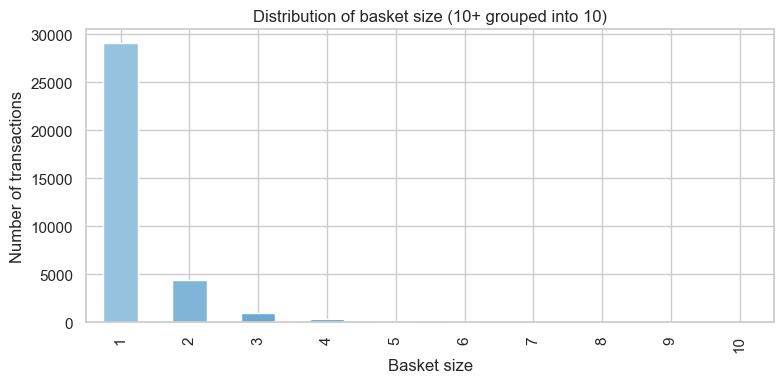

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = transaction_sizes.clip(upper=10).value_counts().sort_index()
colors = sns.color_palette("Blues_d", len(counts))
counts.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Distribution of basket size (10+ grouped into 10)")
ax.set_xlabel("Basket size")
ax.set_ylabel("Number of transactions")
plt.tight_layout()
plt.show()


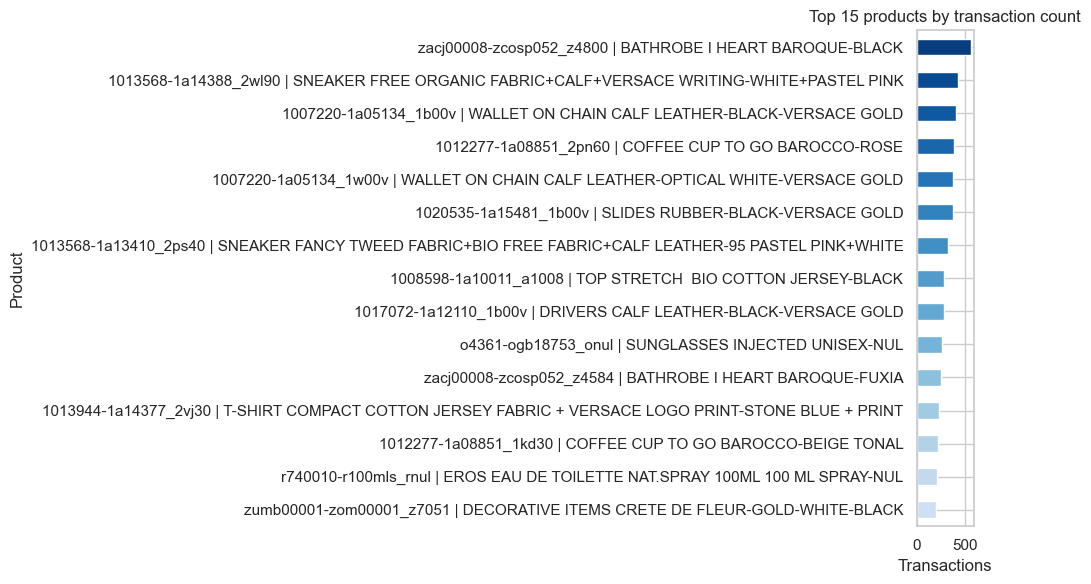

In [7]:
# Top products by transaction count
product_tx = (
    mba.groupby("product_label")["transaction_id"]
       .nunique()
       .sort_values(ascending=False)
)

#display(product_tx.head(15).rename("transactions").to_frame())

plot_data = product_tx.head(15).sort_values()
colors = sns.color_palette("Blues", len(plot_data) + 3)[3:]
fig, ax = plt.subplots(figsize=(10, 6))
plot_data.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 15 products by transaction count")
ax.set_xlabel("Transactions")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()


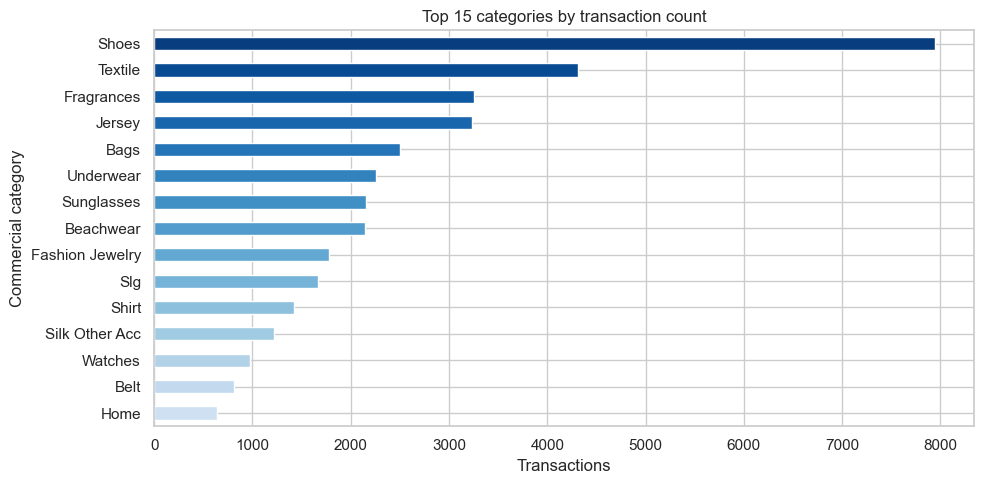

In [8]:
# Top categories by transaction count
category_tx = (
    mba.groupby("commercial_category")["transaction_id"]
       .nunique()
       .sort_values(ascending=False)
)

#display(category_tx.head(15).rename("transactions").to_frame())

plot_data = category_tx.head(15).sort_values()
colors = sns.color_palette("Blues", len(plot_data) + 3)[3:]
fig, ax = plt.subplots(figsize=(10, 5))
plot_data.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 15 categories by transaction count")
ax.set_xlabel("Transactions")
ax.set_ylabel("Commercial category")
plt.tight_layout()
plt.show()


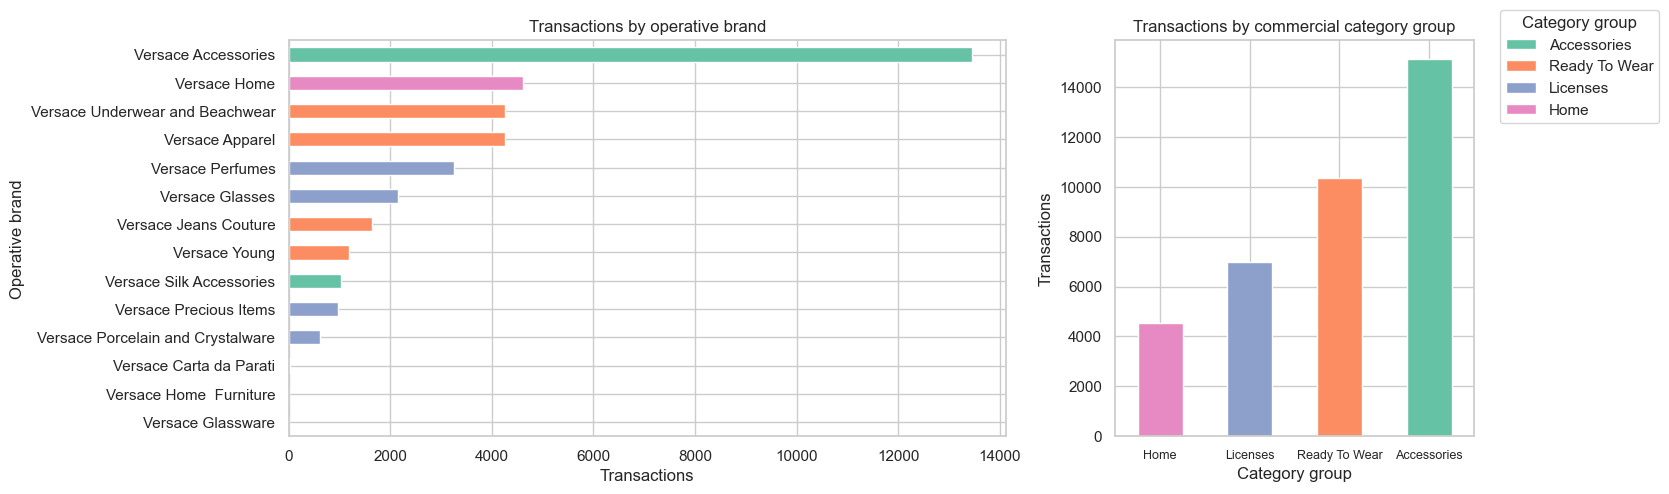

In [ ]:
# --- Transactions by operative brand ---
brand_tx = (
    mba.groupby("operative_brand")["transaction_id"]
       .nunique()
       .sort_values(ascending=False)
)

# Dominant commercial_category_group for each brand
dominant_group = (
    mba.groupby(["operative_brand", "commercial_category_group"])
       .size()
       .reset_index(name="n")
       .sort_values("n", ascending=False)
       .drop_duplicates("operative_brand")
       .set_index("operative_brand")["commercial_category_group"]
)

# --- Transactions by commercial category group ---
cat_group_tx = (
    mba.groupby("commercial_category_group")["transaction_id"]
       .nunique()
       .sort_values(ascending=False)
)

# Shared Set2 palette
category_order = ["Accessories", "Ready To Wear", "Licenses", "Home"]
group_palette = dict(zip(category_order, sns.color_palette("Set2", len(category_order))))

# Plot ordering
brand_plot_data = brand_tx.sort_values()
cat_plot_data = cat_group_tx.sort_values()

brand_colors = [
    group_palette[dominant_group.loc[brand]]
    for brand in brand_plot_data.index
]

cat_colors = [
    group_palette[group]
    for group in cat_plot_data.index
]

# --- Combined figure ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [2, 1]}
)

# Plot 1: operative brand
brand_plot_data.plot(
    kind="barh",
    ax=axes[0],
    color=brand_colors,
    edgecolor="white"
)

axes[0].set_title("Transactions by operative brand")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Operative brand")

# Plot 2: category group
cat_plot_data.plot(
    kind="bar",
    ax=axes[1],
    color=cat_colors,
    edgecolor="white"
)

axes[1].set_title("Transactions by commercial category group")
axes[1].set_xlabel("Category group")
axes[1].set_ylabel("Transactions")
axes[1].set_xticklabels(cat_plot_data.index, rotation=0, fontsize=9)
# Shared legend
legend_handles = [
    Patch(facecolor=col, label=grp)
    for grp, col in group_palette.items()
]

fig.legend(
    handles=legend_handles,
    title="Category group",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

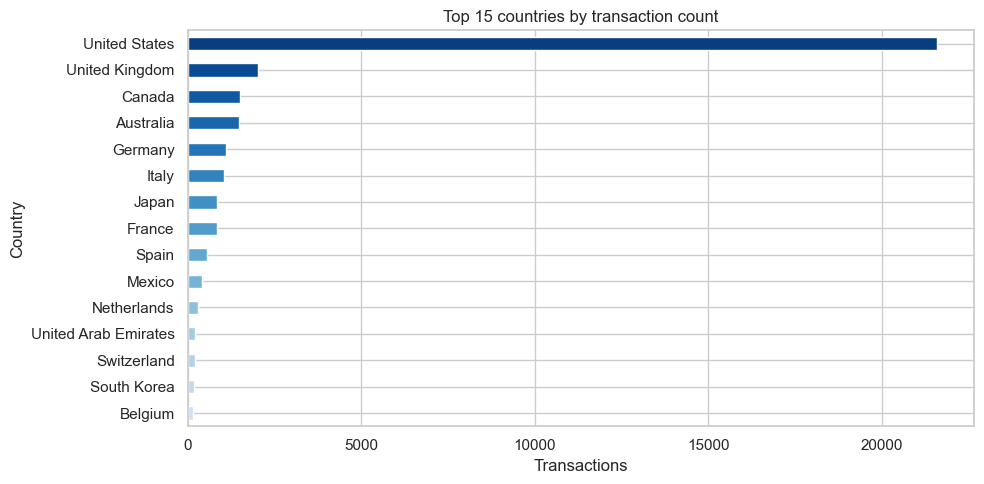

In [11]:
# Top countries by transaction count
country_tx = (
    mba.groupby("country")["transaction_id"]
       .nunique()
       .sort_values(ascending=False)
)

# display(country_tx.head(15).rename("transactions").to_frame())

plot_data = country_tx.head(15).sort_values()
colors = sns.color_palette("Blues", len(plot_data) + 3)[3:]
fig, ax = plt.subplots(figsize=(10, 5))
plot_data.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 15 countries by transaction count")
ax.set_xlabel("Transactions")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()


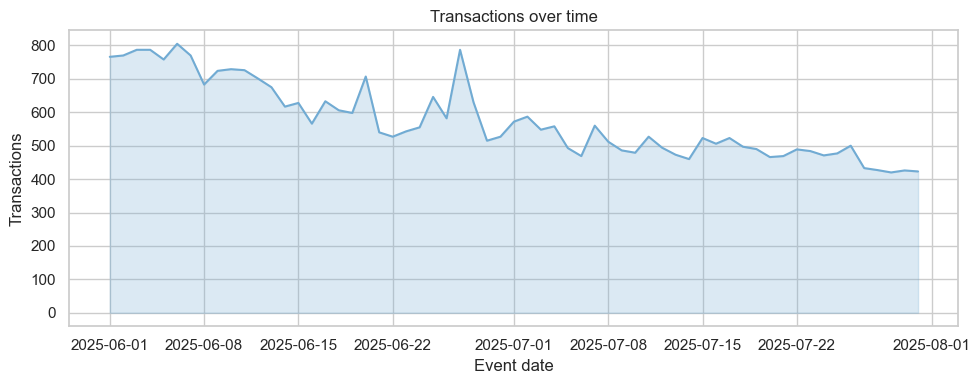

In [12]:
# Purchases over time
transactions_per_day = mba.groupby("event_date")["transaction_id"].nunique().sort_index()

#display(transactions_per_day.head().rename("transactions").to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
accent = sns.color_palette("Blues_d", 3)[0]
ax.fill_between(transactions_per_day.index, transactions_per_day.values, alpha=0.25, color=accent)
ax.plot(transactions_per_day.index, transactions_per_day.values, color=accent, linewidth=1.5)
ax.set_title("Transactions over time")
ax.set_xlabel("Event date")
ax.set_ylabel("Transactions")
plt.tight_layout()
plt.show()


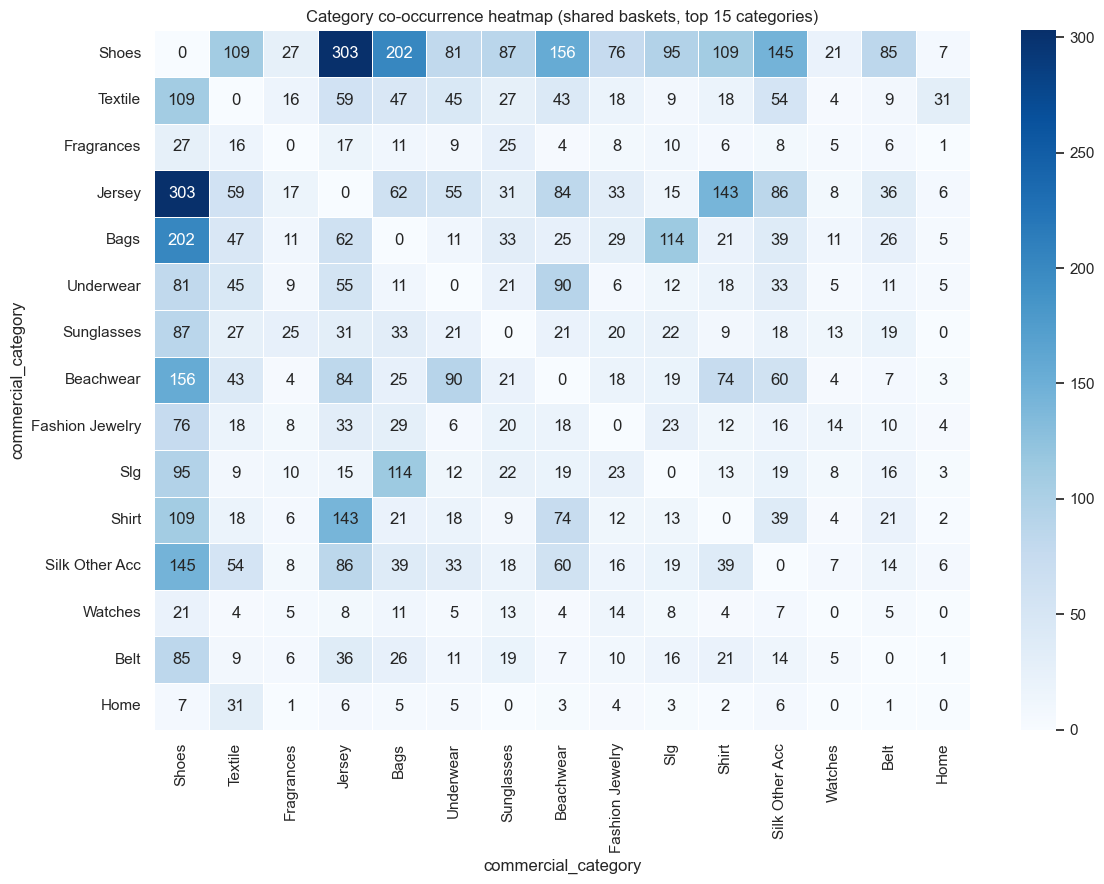

In [13]:
# Category co-occurrence heatmap
top_cats = category_tx.head(15).index.tolist()
mba_top = mba[mba["commercial_category"].isin(top_cats)]

basket_cat = (
    mba_top.groupby(["transaction_id", "commercial_category"])
           .size()
           .unstack(fill_value=0)
           .clip(upper=1)
           .reindex(columns=top_cats, fill_value=0)
)
cooc = basket_cat.T.dot(basket_cat)
import numpy as _np; _np.fill_diagonal(cooc.values, 0)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cooc, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white", ax=ax
)
ax.set_title("Category co-occurrence heatmap (shared baskets, top 15 categories)")
plt.tight_layout()
plt.show()


# 3. Association-rule functions

In [14]:
def build_item_brand_map(df: pd.DataFrame) -> pd.DataFrame:
    mapping = (
        df[['product_label', 'operative_brand']]
        .drop_duplicates()
        .rename(columns={'product_label': 'item', 'operative_brand': 'operative_brand'})
    )
    return mapping


item_brand_map = build_item_brand_map(mba)


def generate_pair_rules_custom(df, basket_col, item_col, min_item_baskets=20, min_pair_baskets=3):
    """
    Custom pairwise association-rule miner.
    Returns directional rules A -> B with support, confidence and lift.
    This is equivalent to standard MBA outputs for 2-item rules.
    """
    n_baskets = df[basket_col].nunique()
    item_basket_counts = (
        df.groupby(item_col)[basket_col]
          .nunique()
          .sort_values(ascending=False)
    )
    kept_items = set(item_basket_counts[item_basket_counts >= min_item_baskets].index)

    baskets = (
        df.groupby(basket_col)[item_col]
          .apply(lambda s: sorted(set(x for x in s if x in kept_items)))
    )

    pair_counter = Counter()
    for items in baskets:
        if len(items) < 2:
            continue
        for a, b in combinations(items, 2):
            pair_counter[(a, b)] += 1

    rows = []
    for (a, b), pair_count in pair_counter.items():
        if pair_count < min_pair_baskets:
            continue

        supp_ab = pair_count / n_baskets
        supp_a = item_basket_counts[a] / n_baskets
        supp_b = item_basket_counts[b] / n_baskets
        lift = supp_ab / (supp_a * supp_b)

        rows.append({
            'focal_item': a,
            'associated_item': b,
            'focal_baskets': int(item_basket_counts[a]),
            'associated_baskets': int(item_basket_counts[b]),
            'pair_baskets': int(pair_count),
            'joint_purchase_probability_given_focal': pair_count / item_basket_counts[a],
            'support': supp_ab,
            'lift': lift,
        })
        rows.append({
            'focal_item': b,
            'associated_item': a,
            'focal_baskets': int(item_basket_counts[b]),
            'associated_baskets': int(item_basket_counts[a]),
            'pair_baskets': int(pair_count),
            'joint_purchase_probability_given_focal': pair_count / item_basket_counts[b],
            'support': supp_ab,
            'lift': lift,
        })

    rules = pd.DataFrame(rows)
    if rules.empty:
        return rules

    return rules.sort_values(
        ['lift', 'joint_purchase_probability_given_focal', 'pair_baskets'],
        ascending=[False, False, False]
    ).reset_index(drop=True)


# Optional mlxtend route if installed

def generate_pair_rules_mlxtend(df, basket_col, item_col, min_item_baskets=20, min_pair_baskets=3):
    basket_items = (
        df.groupby(basket_col)[item_col]
          .apply(lambda s: sorted(set(s)))
    )

    item_counts = Counter()
    for items in basket_items:
        item_counts.update(items)
    kept_items = {k for k, v in item_counts.items() if v >= min_item_baskets}

    filtered = basket_items.apply(lambda items: [x for x in items if x in kept_items])
    filtered = filtered[filtered.str.len() > 0]

    if filtered.empty:
        return pd.DataFrame()

    onehot = pd.DataFrame(
        [{item: True for item in items} for items in filtered],
        index=filtered.index
    ).fillna(False)

    freq = apriori(onehot, min_support=min_pair_baskets / len(filtered), use_colnames=True)
    if freq.empty:
        return pd.DataFrame()

    rules = association_rules(freq, metric='support', min_threshold=min_pair_baskets / len(filtered))
    rules = rules[
        (rules['antecedents'].apply(len) == 1) &
        (rules['consequents'].apply(len) == 1)
    ].copy()

    rules['focal_item'] = rules['antecedents'].apply(lambda s: next(iter(s)))
    rules['associated_item'] = rules['consequents'].apply(lambda s: next(iter(s)))
    rules['focal_baskets'] = rules['focal_item'].map(item_counts)
    rules['associated_baskets'] = rules['associated_item'].map(item_counts)
    rules['pair_baskets'] = (rules['support'] * len(filtered)).round().astype(int)
    rules['joint_purchase_probability_given_focal'] = rules['confidence']

    out = rules[[
        'focal_item', 'associated_item', 'focal_baskets', 'associated_baskets',
        'pair_baskets', 'joint_purchase_probability_given_focal', 'support', 'lift'
    ]].copy()
    out = out[out['pair_baskets'] >= min_pair_baskets]
    return out.sort_values(
        ['lift', 'joint_purchase_probability_given_focal', 'pair_baskets'],
        ascending=[False, False, False]
    ).reset_index(drop=True)


def generate_pair_rules(df, basket_col, item_col, min_item_baskets=20, min_pair_baskets=3):
    if USE_MLXTEND:
        return generate_pair_rules_mlxtend(df, basket_col, item_col, min_item_baskets, min_pair_baskets)
    return generate_pair_rules_custom(df, basket_col, item_col, min_item_baskets, min_pair_baskets)


# 4. Market Basket Analysis

## 4.1. Product-level 

The table below reports the main **product-level association rules**. Each row is directional: `focal_item -> associated_item`.

- `joint_purchase_probability_given_focal` = probability that the associated product is also present **given** that the focal product is in the basket.
- `support` = share of all baskets containing the pair.
- `lift` = strength of association relative to independence.


In [15]:
product_rules = generate_pair_rules(
    mba,
    basket_col='transaction_id',
    item_col='product_label',
    min_item_baskets=20,
    min_pair_baskets=3,
)

# Operative brand enrichment
product_rules = product_rules.merge(
    item_brand_map.rename(columns={'item': 'focal_item', 'operative_brand': 'focal_operative_brand'}),
    on='focal_item',
    how='left'
).merge(
    item_brand_map.rename(columns={'item': 'associated_item', 'operative_brand': 'associated_operative_brand'}),
    on='associated_item',
    how='left'
)
product_rules['same_operative_brand'] = (
    product_rules['focal_operative_brand'] == product_rules['associated_operative_brand']
)

product_summary = product_rules.copy()
product_summary['support'] = product_summary['support'].round(6)
product_summary['lift'] = product_summary['lift'].round(3)
product_summary['joint_purchase_probability_given_focal'] = product_summary['joint_purchase_probability_given_focal'].round(4)

product_summary_path = OUTPUT_DIR / 'product_level_association_summary.csv'
product_summary.to_csv(product_summary_path, index=False)

print('Number of directional product rules:', len(product_summary))
print('Saved:', product_summary_path)
display(product_summary.head(25))


Number of directional product rules: 534
Saved: D:\claude\Versace\versace_part_b_outputs\product_level_association_summary.csv


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift,focal_operative_brand,associated_operative_brand,same_operative_brand
0,1008603-1a11119_1pv80 | SWIM BOTTOM RECYCLED LYCRA-GUAVA,1020489-1a11119_1pv80 | SWIM BIKINI RECYCLED LYCRA-GUAVA,37,37,31,0.8378,0.0009,795.0180,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
1,1020489-1a11119_1pv80 | SWIM BIKINI RECYCLED LYCRA-GUAVA,1008603-1a11119_1pv80 | SWIM BOTTOM RECYCLED LYCRA-GUAVA,37,37,31,0.8378,0.0009,795.0180,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
2,1016592-1a15467_5k660 | SWIMSUIT LYCRA RENEWSTYLE LIGHT UNDERWATER BAROCCO PLACED PR-EGGSHELL+DRAGONFRUIT,iba0005-1a15542_5k660 | BANDEAUX 5X86 BIO ILK TWILL UNDERWATER BAROCCO BICOLOUR-EGGSHELL+DRAGONFRUIT,20,21,6,0.3000,0.0002,501.5570,Versace Underwear and Beachwear,Versace Silk Accessories,False
3,iba0005-1a15542_5k660 | BANDEAUX 5X86 BIO ILK TWILL UNDERWATER BAROCCO BICOLOUR-EGGSHELL+DRAGONFRUIT,1016592-1a15467_5k660 | SWIMSUIT LYCRA RENEWSTYLE LIGHT UNDERWATER BAROCCO PLACED PR-EGGSHELL+DRAGONFRUIT,21,20,6,0.2857,0.0002,501.5570,Versace Silk Accessories,Versace Underwear and Beachwear,False
4,1018127-1a12917_1b000 | SWIM BIKINI LYCRA VITA RECYCLED+PIN FORM-BLACK,1018128-1a12917_1b000 | SWIM SLIP LYCRA VITA RECYCLED+PIN FORM-BLACK,50,50,35,0.7000,0.0010,491.5260,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
5,1018128-1a12917_1b000 | SWIM SLIP LYCRA VITA RECYCLED+PIN FORM-BLACK,1018127-1a12917_1b000 | SWIM BIKINI LYCRA VITA RECYCLED+PIN FORM-BLACK,50,50,35,0.7000,0.0010,491.5260,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
6,1001381-1a10011_1pv90 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-DRAGON FRUIT,aud01039-1a10011_1pv90 | BRA STRETCH BIO COTTON JERSEY-DRAGON FRUIT,32,46,18,0.5625,0.0005,429.3220,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
7,aud01039-1a10011_1pv90 | BRA STRETCH BIO COTTON JERSEY-DRAGON FRUIT,1001381-1a10011_1pv90 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-DRAGON FRUIT,46,32,18,0.3913,0.0005,429.3220,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
8,1016576-1a15491_5k640 | SWIM SHORTS TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,1016588-1a15491_5k640 | OTHER BEACHWEAR TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,33,63,25,0.7576,0.0007,422.1860,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
9,1016588-1a15491_5k640 | OTHER BEACHWEAR TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,1016576-1a15491_5k640 | SWIM SHORTS TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,63,33,25,0.3968,0.0007,422.1860,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True


In [16]:

# Stronger product rules for business interpretation
strong_product_rules = (
    product_summary[product_summary['pair_baskets'] >= 5]
    .sort_values(['lift', 'joint_purchase_probability_given_focal', 'pair_baskets'], ascending=[False, False, False])
    .head(20)
)

display(strong_product_rules)


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift,focal_operative_brand,associated_operative_brand,same_operative_brand
0,1008603-1a11119_1pv80 | SWIM BOTTOM RECYCLED LYCRA-GUAVA,1020489-1a11119_1pv80 | SWIM BIKINI RECYCLED LYCRA-GUAVA,37,37,31,0.8378,0.0009,795.0180,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
1,1020489-1a11119_1pv80 | SWIM BIKINI RECYCLED LYCRA-GUAVA,1008603-1a11119_1pv80 | SWIM BOTTOM RECYCLED LYCRA-GUAVA,37,37,31,0.8378,0.0009,795.0180,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
2,1016592-1a15467_5k660 | SWIMSUIT LYCRA RENEWSTYLE LIGHT UNDERWATER BAROCCO PLACED PR-EGGSHELL+DRAGONFRUIT,iba0005-1a15542_5k660 | BANDEAUX 5X86 BIO ILK TWILL UNDERWATER BAROCCO BICOLOUR-EGGSHELL+DRAGONFRUIT,20,21,6,0.3000,0.0002,501.5570,Versace Underwear and Beachwear,Versace Silk Accessories,False
3,iba0005-1a15542_5k660 | BANDEAUX 5X86 BIO ILK TWILL UNDERWATER BAROCCO BICOLOUR-EGGSHELL+DRAGONFRUIT,1016592-1a15467_5k660 | SWIMSUIT LYCRA RENEWSTYLE LIGHT UNDERWATER BAROCCO PLACED PR-EGGSHELL+DRAGONFRUIT,21,20,6,0.2857,0.0002,501.5570,Versace Silk Accessories,Versace Underwear and Beachwear,False
4,1018127-1a12917_1b000 | SWIM BIKINI LYCRA VITA RECYCLED+PIN FORM-BLACK,1018128-1a12917_1b000 | SWIM SLIP LYCRA VITA RECYCLED+PIN FORM-BLACK,50,50,35,0.7000,0.0010,491.5260,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
5,1018128-1a12917_1b000 | SWIM SLIP LYCRA VITA RECYCLED+PIN FORM-BLACK,1018127-1a12917_1b000 | SWIM BIKINI LYCRA VITA RECYCLED+PIN FORM-BLACK,50,50,35,0.7000,0.0010,491.5260,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
6,1001381-1a10011_1pv90 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-DRAGON FRUIT,aud01039-1a10011_1pv90 | BRA STRETCH BIO COTTON JERSEY-DRAGON FRUIT,32,46,18,0.5625,0.0005,429.3220,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
7,aud01039-1a10011_1pv90 | BRA STRETCH BIO COTTON JERSEY-DRAGON FRUIT,1001381-1a10011_1pv90 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-DRAGON FRUIT,46,32,18,0.3913,0.0005,429.3220,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
8,1016576-1a15491_5k640 | SWIM SHORTS TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,1016588-1a15491_5k640 | OTHER BEACHWEAR TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,33,63,25,0.7576,0.0007,422.1860,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
9,1016588-1a15491_5k640 | OTHER BEACHWEAR TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,1016576-1a15491_5k640 | SWIM SHORTS TEX VOILE COTONE UNDERWATER BAROCCO PRINT-EGGSHELL+MULTICOLOR,63,33,25,0.3968,0.0007,422.1860,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True


In [17]:

brand_pair_summary = (
    strong_product_rules.groupby('same_operative_brand')
    .agg(
        rules=('focal_item', 'size'),
        avg_lift=('lift', 'mean'),
        avg_pair_baskets=('pair_baskets', 'mean')
    )
    .reset_index()
)

display(brand_pair_summary)


,same_operative_brand,rules,avg_lift,avg_pair_baskets
0,False,2,501.5570,6.0000
1,True,18,419.0328,24.2222


## 4.2. Category-level Market Basket Analysis

The next table applies the same logic to **commercial categories** rather than individual products, which is usually easier to translate into cross-selling and site-merchandising actions.


In [18]:

category_rules = generate_pair_rules(
    mba,
    basket_col='transaction_id',
    item_col='commercial_category',
    min_item_baskets=30,
    min_pair_baskets=5,
)

category_summary = category_rules.copy()
category_summary['support'] = category_summary['support'].round(6)
category_summary['lift'] = category_summary['lift'].round(3)
category_summary['joint_purchase_probability_given_focal'] = category_summary['joint_purchase_probability_given_focal'].round(4)

category_summary_path = OUTPUT_DIR / 'category_level_association_summary.csv'
category_summary.to_csv(category_summary_path, index=False)

print('Number of directional category rules:', len(category_summary))
print('Saved:', category_summary_path)
display(category_summary.head(30))


Number of directional category rules: 350
Saved: D:\claude\Versace\versace_part_b_outputs\category_level_association_summary.csv


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift
0,Bodysuit,Gift Set,37,77,10,0.2703,0.0003,123.2330
1,Gift Set,Bodysuit,77,37,10,0.1299,0.0003,123.2330
2,Outdoor Blanket,Gift Set,61,77,15,0.2459,0.0004,112.1220
3,Gift Set,Outdoor Blanket,77,61,15,0.1948,0.0004,112.1220
4,Bodysuit,Outdoor Blanket,37,61,5,0.1351,0.0001,77.7780
5,Outdoor Blanket,Bodysuit,61,37,5,0.0820,0.0001,77.7780
6,Jacket,Skirt,100,181,13,0.1300,0.0004,25.2160
7,Skirt,Jacket,181,100,13,0.0718,0.0004,25.2160
8,Jacket,Pants,100,597,38,0.3800,0.0011,22.3470
9,Pants,Jacket,597,100,38,0.0637,0.0011,22.3470


In [19]:

# Stronger category rules for business interpretation
business_category_rules = (
    category_summary[category_summary['pair_baskets'] >= 10]
    .sort_values(['lift', 'joint_purchase_probability_given_focal', 'pair_baskets'], ascending=[False, False, False])
    .head(20)
)

display(business_category_rules)


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift
0,Bodysuit,Gift Set,37,77,10,0.2703,0.0003,123.2330
1,Gift Set,Bodysuit,77,37,10,0.1299,0.0003,123.2330
2,Outdoor Blanket,Gift Set,61,77,15,0.2459,0.0004,112.1220
3,Gift Set,Outdoor Blanket,77,61,15,0.1948,0.0004,112.1220
6,Jacket,Skirt,100,181,13,0.1300,0.0004,25.2160
7,Skirt,Jacket,181,100,13,0.0718,0.0004,25.2160
8,Jacket,Pants,100,597,38,0.3800,0.0011,22.3470
9,Pants,Jacket,597,100,38,0.0637,0.0011,22.3470
10,Skirt,Knitwear,181,294,15,0.0829,0.0004,9.8970
11,Knitwear,Skirt,294,181,15,0.0510,0.0004,9.8970


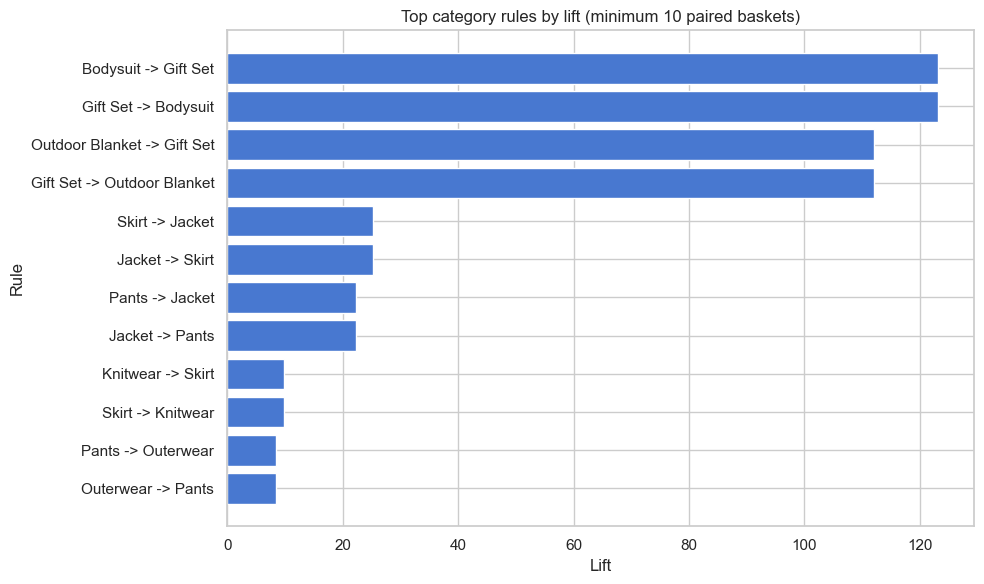

In [20]:

plot_df = business_category_rules.copy().head(12)
plot_df['rule'] = plot_df['focal_item'] + ' -> ' + plot_df['associated_item']
plot_df = plot_df.sort_values('lift')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['rule'], plot_df['lift'])
ax.set_title('Top category rules by lift (minimum 10 paired baskets)')
ax.set_xlabel('Lift')
ax.set_ylabel('Rule')
plt.tight_layout()
plt.show()


# 5. Recommendation tables

In [21]:

def top_n_recommendations(rules_df, n=3):
    return (
        rules_df.sort_values(
            ['focal_item', 'lift', 'joint_purchase_probability_given_focal', 'pair_baskets'],
            ascending=[True, False, False, False]
        )
        .groupby('focal_item', as_index=False)
        .head(n)
        .reset_index(drop=True)
    )

product_recos = top_n_recommendations(product_summary, n=3)
category_recos = top_n_recommendations(category_summary, n=3)

product_recos_path = OUTPUT_DIR / 'product_top3_recommendations.csv'
category_recos_path = OUTPUT_DIR / 'category_top3_recommendations.csv'

product_recos.to_csv(product_recos_path, index=False)
category_recos.to_csv(category_recos_path, index=False)

print('Saved:', product_recos_path)
print('Saved:', category_recos_path)
display(product_recos.head(15))
display(category_recos.head(15))


Saved: D:\claude\Versace\versace_part_b_outputs\product_top3_recommendations.csv
Saved: D:\claude\Versace\versace_part_b_outputs\category_top3_recommendations.csv


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift,focal_operative_brand,associated_operative_brand,same_operative_brand
0,1001381-1a10011_1pv90 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-DRAGON FRUIT,aud01039-1a10011_1pv90 | BRA STRETCH BIO COTTON JERSEY-DRAGON FRUIT,32,46,18,0.5625,0.0005,429.3220,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
1,1001381-1a10011_a1008 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-BLACK,aud01039-1a10011_a1008 | BRA STRETCH BIO COTTON JERSEY-BLACK,28,74,6,0.2143,0.0002,101.6670,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
2,1001381-1a10011_a1008 | BRASILIAN SLIP STRETCH BIO COTTON JERSEY-BLACK,1008598-1a10011_a1008 | TOP STRETCH BIO COTTON JERSEY-BLACK,28,286,8,0.2857,0.0002,35.0740,Versace Underwear and Beachwear,Versace Underwear and Beachwear,True
3,1003926-1a13397_5b950 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-BLACK+SILVER,1003926-1a13397_5ud30 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-95PASTEL BLUE+GOLD,58,45,4,0.0690,0.0001,53.8070,Versace Apparel,Versace Apparel,True
4,1003926-1a13397_5b950 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-BLACK+SILVER,1018883-1a13627_5b950 | SWIM SHORTS NYLON GOLFO RECYCLED MEDUSA CHAINS PRINT-BLACK+SILVER,58,49,4,0.0690,0.0001,49.4140,Versace Apparel,Versace Underwear and Beachwear,False
5,1003926-1a13397_5b950 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-BLACK+SILVER,1018884-1a13627_5b950 | SWIM SHORTS NYLON GOLFO RECYCLED MEDUSA CHAINS PRINT-BLACK+SILVER,58,61,4,0.0690,0.0001,39.6940,Versace Apparel,Versace Underwear and Beachwear,False
6,1003926-1a13397_5ud30 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-95PASTEL BLUE+GOLD,1003926-1a13397_5b950 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-BLACK+SILVER,45,58,4,0.0889,0.0001,53.8070,Versace Apparel,Versace Apparel,True
7,1003926-1a13397_5ud30 | INFORMAL SHIRT MEDUSA CHAINS PRINT SILK TWILL-95PASTEL BLUE+GOLD,1018883-1a13627_5ud30 | SWIM SHORTS NYLON GOLFO RECYCLED MEDUSA CHAINS PRINT-95PASTEL BLUE+GOLD,45,49,3,0.0667,0.0001,47.7670,Versace Apparel,Versace Underwear and Beachwear,False
8,1003926-1a14567_5b020 | INFORMAL SHIRT SILK TWILL CORAL THEATRE PRINT-BLACK+MULTICOLOR,1003926-1a14567_5ga00 | INFORMAL SHIRT SILK TWILL CORAL THEATRE PRINT-SEA GREEN+DARK SEA GREEN,33,23,4,0.1212,0.0001,185.0280,Versace Apparel,Versace Apparel,True
9,1003926-1a14567_5ga00 | INFORMAL SHIRT SILK TWILL CORAL THEATRE PRINT-SEA GREEN+DARK SEA GREEN,1003926-1a14567_5b020 | INFORMAL SHIRT SILK TWILL CORAL THEATRE PRINT-BLACK+MULTICOLOR,23,33,4,0.1739,0.0001,185.0280,Versace Apparel,Versace Apparel,True


,focal_item,associated_item,focal_baskets,associated_baskets,pair_baskets,joint_purchase_probability_given_focal,support,lift
0,Activewear,Jersey,36,3237,19,0.5278,0.0005,5.7240
1,Bags,Slg,2502,1670,114,0.0456,0.0032,0.9580
2,Bags,Belt,2502,808,26,0.0104,0.0007,0.4520
3,Bags,Silk Other Acc,2502,1217,39,0.0156,0.0011,0.4500
4,Beachwear,Pants,2149,597,35,0.0163,0.0010,0.9580
5,Beachwear,Shirt,2149,1425,74,0.0344,0.0021,0.8480
6,Beachwear,Silk Other Acc,2149,1217,60,0.0279,0.0017,0.8050
7,Belt,Denim/Jeans,808,439,9,0.0111,0.0003,0.8910
8,Belt,Pants,808,597,10,0.0124,0.0003,0.7280
9,Belt,Shirt,808,1425,21,0.0260,0.0006,0.6400


# 6. Business interpretation


## Main empirical takeaways
- The dataset is extremely sparse: about **82.7% of baskets contain only one item**, so pairwise rules are more informative than longer itemsets.
- The strongest product-level rules often reflect **coordinated sets** or highly complementary products.
- At category level, the analysis highlights interpretable combinations that can inform **cross-selling widgets**, **bundling**, and **visual merchandising**.
- The operative-brand enrichment helps separate rules that are mainly **within-brand** from those that reveal **cross-brand** opportunities.

## Recommended actions for Versace
**Rule selection & prioritization**
- Prioritize category pairs with both meaningful **pair_baskets** and high **lift**, not lift alone.
- For presentation purposes, focus on a small set of rules that are both statistically strong and easy to explain to a managerial audience.

**Site placement & cross-selling**
- Use the strongest rules to power **"Complete the look"** and **"Frequently bought together"** modules on PDP and cart pages.
- Build bundles around coordinated sets (for example, matching swimwear or tops and bottoms) where the conditional joint-purchase probability is high.

**Brand strategy**
- Use the operative-brand information to decide whether recommendations should stay within the same brand architecture or deliberately expose complementary cross-brand items.


